# CSCN 8020 — Reinforcement Learning Programming
## Assignment 1

| Field | Details |
|---|---|
| **Student Name** | Sumanth Reddy Konannagari |
| **Student ID** | 9040660 |
| **GitHub Repository** | https://github.com/SumanthReddyKConestoga/CSCN8020_Assignment1.git |
| **Course** | CSCN 8020 — Reinforcement Learning Programming |


## Software Architecture

```
CSCN8020_Assignment1/
├── CSCN8020_Assignment1.ipynb   # This notebook
├── src/
│   ├── environments.py          # GridWorldEnvironment (Gymnasium), GridWorld2x2
│   ├── agents.py                # ValueIterationAgent, InPlaceValueIterationAgent, MonteCarloAgent
│   ├── policies.py              # GreedyPolicy, UniformPolicy, EpsilonGreedyPolicy
│   └── utils.py                 # setup_logging, ExperimentRunner, Visualiser, Logger
├── logs/
│   └── execution.log            # Generated on notebook run
├── images/                      # Saved figures
├── README.md
├── requirements.txt
└── .gitignore
```

## References
1. Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
2. Precup, D., Sutton, R. S., & Singh, S. (2000). Eligibility Traces for Off-Policy Policy Evaluation. *ICML 2000*.
3. Silver, D. (2015). *Lectures on Reinforcement Learning*. UCL / DeepMind.
4. Nasr, M. (2023). CSCN 8020 Lecture Slides — Lectures 3 & 4. Conestoga College.
5. Course Playground: https://github.com/CSCN8020/playground/tree/main/lec3_DP
6. Course Playground: https://github.com/CSCN8020/playground/tree/main/lec4_MC


## Setup: Imports, Logging, Environment

In [2]:
import sys, os
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib import cm
import timeit

# Import OOP modules from src/
from src.environments import GridWorldEnvironment, GridWorld2x2
from src.agents       import ValueIterationAgent, InPlaceValueIterationAgent, MonteCarloAgent
from src.policies     import GreedyPolicy, UniformPolicy
from src.utils        import setup_logging, ExperimentRunner, Visualiser, Logger

# ── Logging setup: writes to logs/execution.log AND console ──────────
root_logger = setup_logging(log_dir='logs', log_file='execution.log')
exp_logger  = Logger('Assignment1')

np.random.seed(42)
print("All imports successful.")
print("Log file: logs/execution.log")


2026-06-11 22:26:44 | INFO     | root                           | ======================================================================
2026-06-11 22:26:44 | INFO     | root                           | CSCN 8020 Assignment 1 — Execution Log
2026-06-11 22:26:44 | INFO     | root                           | Started at: 2026-06-11 22:26:44
2026-06-11 22:26:44 | INFO     | root                           | Log file  : logs\execution.log
2026-06-11 22:26:44 | INFO     | root                           | ======================================================================


All imports successful.
Log file: logs/execution.log


---
## Problem 1 [10 Marks] — Pick-and-Place Robot: MDP Design

### Problem Statement
Design the reinforcement learning problem for a pick-and-place robot arm as an MDP.
Define states, actions, and rewards with reasoning.

---

### Talking Point A — Key RL Feature: MDP Formalism

The **Markov Decision Process** is the mathematical framework that underpins all RL problems.
Formally defined as a 5-tuple $M = (S, A, P, R, \gamma)$, it captures the complete
interaction between an agent and an environment. The Markov property ensures the next state
depends only on the current state and action — not the full history — enabling tractable
dynamic programming solutions (Sutton & Barto, 2018, Chapter 3).

---

### Talking Point B — Implementation Challenge: State Representation

The key challenge in designing this MDP is choosing a state representation that satisfies
the Markov property. Including only joint angles $\theta_i$ is insufficient because two
configurations with identical angles but different velocities will evolve differently under
the same action. The state must include angular velocities $\dot{\theta}_i$ to be Markovian.
This increases the state space dimensionality but is necessary for correctness.

---

### Talking Point C — Why This Is Reinforcement Learning

This solution is RL — not supervised or unsupervised ML — because:
1. **No labelled data:** the agent learns from interaction, not pre-labelled examples.
2. **Reward signal:** the agent receives scalar feedback (+100 for task, penalties otherwise).
3. **Sequential decisions:** actions affect future states (temporal credit assignment).
4. **Trial-and-error:** the agent must explore the state-action space to discover
   good motor torque sequences.

Mapping to Sutton & Barto pseudocode: the pick-and-place task is an **episodic MDP**
(Definition 3.1, p.54). The agent, environment, state, action, reward, and return
$G_t = \sum_{k=0}^{T} \gamma^k R_{t+k+1}$ are all defined below.

---

### 1.1 Formal MDP Definition

$$M = (S,\; A,\; P,\; R,\; \gamma)$$

---

### 1.2 State Space $S$

**Markov Property:** $P(s_{t+1}|s_t) = P(s_{t+1}|s_0,s_1,\ldots,s_t)$

For a robot arm with $n$ joints:
$$s = (\theta_1, \dot{\theta}_1,\; \theta_2, \dot{\theta}_2,\; \ldots,\; \theta_n, \dot{\theta}_n,\; x_{obj}, y_{obj}, z_{obj})$$

| Variable | Description | Why Needed |
|---|---|---|
| $\theta_i$ | Joint angle of link $i$ (rad) | Defines arm configuration via forward kinematics |
| $\dot{\theta}_i$ | Angular velocity of joint $i$ (rad/s) | Required for Markov property — same angle, different speed = different future |
| $x_{obj},y_{obj},z_{obj}$ | Object position (metres) | Defines the pick target for reward computation |

---

### 1.3 Action Space $A$

$$a = (\tau_1, \tau_2, \ldots, \tau_n) \in \mathbb{R}^n \quad \text{(motor torques, Nm)}$$

Discretized: $A = \{\tau_{min}, \ldots, 0, \ldots, \tau_{max}\}^n$

**Justification:** Direct motor torque control enables the agent to learn smooth trajectories
without relying on pre-programmed motion primitives.

---

### 1.4 Reward Function $R(s, a, s')$

$$R(s,a,s') = w_1 \cdot R_{task} - w_2 \cdot R_{smooth} - w_3 \cdot R_{speed} - w_4 \cdot R_{collision}$$

| Component | Formula (non-negative magnitude) | Weight | Reasoning |
|---|---|---|---|
| Task completion | $R_{task} = \mathbb{1}[s'=s_{goal}]$ | $w_1=100$ | Primary objective; largest weight |
| Smoothness penalty | $R_{smooth} = \sum_i \|\dddot{\theta}_i\|^2$ | $w_2=0.05$ | Penalises jerk (3rd derivative); enforces smooth motion |
| Speed penalty | $R_{speed} = \Delta t$ | $w_3=0.10$ | Per-timestep cost; encourages fast completion |
| Collision penalty | $R_{collision} = \mathbb{1}[collision]$ | $w_4=50$ | Hard deterrent; large but does not override task signal |

> **Sign convention:** All component terms are **non-negative magnitudes**.
> Task reward is added; all penalty terms are explicitly subtracted.
> Weight ordering: $w_1 \gg w_4 \gg w_3 > w_2$ ensures task completion always dominates.

Expanded:
$$R = 100\cdot\mathbb{1}[s'=s_{goal}] - 0.05\sum_i\|\dddot{\theta}_i\|^2 - 0.10\Delta t - 50\cdot\mathbb{1}[collision]$$

---

### 1.5 Transition Dynamics $P(s'|s,a)$

The environment is **deterministic**:
$$P(s'|s,a) = \mathbb{1}[s' = f(s,a)]$$

where $f(s,a)$ integrates the Euler-Lagrange robot dynamics with timestep $\Delta t$:
$$\theta_i^{t+1} = \theta_i^t + \dot{\theta}_i^t\Delta t, \qquad \dot{\theta}_i^{t+1} = \dot{\theta}_i^t + \ddot{\theta}_i^t\Delta t$$

Therefore: $P(s'|s,a)=1$ for the unique computed $s'$, and $0$ for all other states.

---

### 1.6 Episode Structure & Discount Factor

- **Episodic:** terminates when object placed at goal or time $T$ expires.
- **Discount factor:** $\gamma = 0.99$ — close to 1 for long-horizon planning.
  Preserves value signal $\approx 100$ steps ahead while bounding returns.


---
## Problem 2 [20 Marks] — 2x2 Gridworld: Value Iteration

### Problem Statement
Perform two iterations of Value Iteration. Show step-by-step process
including **policy evaluation** and **policy improvement** for each iteration.

---

### Talking Point A — Key RL Feature: Value Iteration

**Value Iteration** is a dynamic programming algorithm that directly computes the optimal
value function $V^*$ by repeatedly applying the Bellman optimality operator:
$$V_{k+1}(s) = \max_a\left[R(s) + \gamma\cdot V_k(s')\right]$$
It combines policy evaluation (computing $V_\pi$) and policy improvement (greedifying)
into a single update, converging to $V^*$ in the limit (Sutton & Barto, 2018, Sec. 4.4).

---

### Talking Point B — Implementation Challenge: Tie-Breaking in Policy Improvement

In Iteration 1, all $V_0 = 0$ so all actions have equal Q-values for every state.
The policy improvement step $\pi_1(s) = \arg\max_a$ must break ties consistently —
defaulting to UP (first action in the ordered set) — to produce a deterministic result.
Without consistent tie-breaking, the policy is non-deterministic and comparisons
between iterations become unreliable.

---

### Talking Point C — Why This Is Reinforcement Learning

Value Iteration is an RL algorithm rooted in the agent-environment interaction loop
(Sutton & Barto, 2018, Figure 3.1). The **value function** $V_\pi(s) = \mathbb{E}_\pi[G_t|S_t=s]$
represents the expected return from state $s$ under policy $\pi$.
The **Bellman optimality equation** is the fixed-point equation that $V^*$ must satisfy.
Unlike supervised learning, no labelled (state, correct-action) pairs exist — the agent
learns purely from the reward structure and transition dynamics.

---

### 2.1 Environment Setup

```
| s1 (R=5)  | s2 (R=10) |     UP    = decrease row index
| s3 (R=1)  | s4 (R=2)  |     DOWN  = increase row index
                               LEFT  = decrease column index
                               RIGHT = increase column index
```

**Assumption:** $\gamma = 1.0$ — not specified in the problem.
Standard choice for finite-horizon manual VI (Sutton & Barto, 2018, Ch. 4.4).
*Sensitivity check:* with $\gamma=0.9$, $V_2(s_1) = 5 + 0.9\times10=14$ instead of 15,
confirming $\gamma=1.0$ produces cleaner integer arithmetic for illustration.

**Full Transition Table:**

| State | UP | DOWN | LEFT | RIGHT |
|---|---|---|---|---|
| s1 (top-left) | s1 (wall) | s3 | s1 (wall) | s2 |
| s2 (top-right) | s2 (wall) | s4 | s1 | s2 (wall) |
| s3 (bottom-left) | s1 | s3 (wall) | s3 (wall) | s4 |
| s4 (bottom-right) | s2 | s4 (wall) | s3 | s4 (wall) |

**Bellman Optimality Equation:**
$$V_{k+1}(s) = \max_a\left[R(s) + \gamma\cdot V_k(s')\right]$$

---

### 2.2 Initialisation: $V_0(s) = 0$ for all $s$

---

### 2.3 ITERATION 1

#### Step A — Policy Evaluation: Compute $V_1$ using $V_0$

**State $s_1$** ($R=5$):

| Action | $s'$ | $R(s_1) + \gamma\cdot V_0(s')$ |
|---|---|---|
| UP | s1 (wall) | $5 + 1.0\times0 = 5$ |
| DOWN | s3 | $5 + 1.0\times0 = 5$ |
| LEFT | s1 (wall) | $5 + 1.0\times0 = 5$ |
| RIGHT | s2 | $5 + 1.0\times0 = 5$ |

$$\boxed{V_1(s_1) = \max(5,5,5,5) = 5}$$

**State $s_2$** ($R=10$):

| Action | $s'$ | $R(s_2) + \gamma\cdot V_0(s')$ |
|---|---|---|
| UP | s2 (wall) | $10 + 1.0\times0 = 10$ |
| DOWN | s4 | $10 + 1.0\times0 = 10$ |
| LEFT | s1 | $10 + 1.0\times0 = 10$ |
| RIGHT | s2 (wall) | $10 + 1.0\times0 = 10$ |

$$\boxed{V_1(s_2) = 10}$$

**State $s_3$** ($R=1$):

| Action | $s'$ | $R(s_3) + \gamma\cdot V_0(s')$ |
|---|---|---|
| UP | s1 | $1 + 1.0\times0 = 1$ |
| DOWN | s3 (wall) | $1 + 1.0\times0 = 1$ |
| LEFT | s3 (wall) | $1 + 1.0\times0 = 1$ |
| RIGHT | s4 | $1 + 1.0\times0 = 1$ |

$$\boxed{V_1(s_3) = \max(1,1,1,1) = 1}$$

**State $s_4$** ($R=2$):

| Action | $s'$ | $R(s_4) + \gamma\cdot V_0(s')$ |
|---|---|---|
| UP | s2 | $2 + 1.0\times0 = 2$ |
| DOWN | s4 (wall) | $2 + 1.0\times0 = 2$ |
| LEFT | s3 | $2 + 1.0\times0 = 2$ |
| RIGHT | s4 (wall) | $2 + 1.0\times0 = 2$ |

$$\boxed{V_1(s_4) = \max(2,2,2,2) = 2}$$

#### Step B — Policy Improvement: Extract $\pi_1$ greedily from $V_1$

$$\pi_1(s) = \arg\max_a[R(s) + \gamma\cdot V_1(s')]$$

All actions tied for every state (all $V_0=0$). Default: **UP** for all states.

---

### 2.4 ITERATION 2

#### Step A — Policy Evaluation: Compute $V_2$ using $V_1$

**State $s_1$** ($R=5$):

| Action | $s'$ | $R(s_1) + \gamma\cdot V_1(s')$ |
|---|---|---|
| UP | s1 (wall) | $5 + 1.0\times5 = 10$ |
| DOWN | s3 | $5 + 1.0\times1 = 6$ |
| LEFT | s1 (wall) | $5 + 1.0\times5 = 10$ |
| **RIGHT** | **s2** | $5 + 1.0\times10 = \mathbf{15}$ |

$$\boxed{V_2(s_1)=15,\quad\pi_2(s_1)=\text{RIGHT}}$$

**State $s_2$** ($R=10$):

| Action | $s'$ | $R(s_2) + \gamma\cdot V_1(s')$ |
|---|---|---|
| **UP** | s2 (wall) | $10 + 1.0\times10 = \mathbf{20}$ |
| DOWN | s4 | $10 + 1.0\times2 = 12$ |
| LEFT | s1 | $10 + 1.0\times5 = 15$ |
| **RIGHT** | s2 (wall) | $10 + 1.0\times10 = \mathbf{20}$ (tie) |

$$\boxed{V_2(s_2)=20,\quad\pi_2(s_2)=\text{UP (tie with RIGHT)}}$$

**State $s_3$** ($R=1$):

| Action | $s'$ | $R(s_3) + \gamma\cdot V_1(s')$ |
|---|---|---|
| **UP** | s1 | $1 + 1.0\times5 = \mathbf{6}$ |
| DOWN | s3 (wall) | $1 + 1.0\times1 = 2$ |
| LEFT | s3 (wall) | $1 + 1.0\times1 = 2$ |
| RIGHT | s4 | $1 + 1.0\times2 = 3$ |

$$\boxed{V_2(s_3)=6,\quad\pi_2(s_3)=\text{UP}}$$

**State $s_4$** ($R=2$):

| Action | $s'$ | $R(s_4) + \gamma\cdot V_1(s')$ |
|---|---|---|
| **UP** | s2 | $2 + 1.0\times10 = \mathbf{12}$ |
| DOWN | s4 (wall) | $2 + 1.0\times2 = 4$ |
| LEFT | s3 | $2 + 1.0\times1 = 3$ |
| RIGHT | s4 (wall) | $2 + 1.0\times2 = 4$ |

$$\boxed{V_2(s_4)=12,\quad\pi_2(s_4)=\text{UP}}$$

#### Step B — Policy Improvement: Extract $\pi_2$ greedily from $V_2$

$$\pi_2(s) = \arg\max_a[R(s) + \gamma\cdot V_2(s')]$$

### 2.5 Final Summary Table

| State | $V_0$ | $V_1$ | $V_2$ | $\pi_1$ | $\pi_2$ |
|---|---|---|---|---|---|
| $s_1$ | 0 | 5 | **15** | UP | **RIGHT** |
| $s_2$ | 0 | 10 | **20** | UP | **UP** |
| $s_3$ | 0 | 1 | **6** | UP | **UP** |
| $s_4$ | 0 | 2 | **12** | UP | **UP** |

> In Iteration 1 all Q-values tie (V0=0). In Iteration 2, $s_1$ correctly points RIGHT
> toward $s_2$ (highest reward R=10) — demonstrating policy improvement.


### 2.6 Code Verification of Manual Results

The assignment requires both manual mathematics AND code verification.
The following code implements Value Iteration on the 2x2 gridworld
and confirms the manually computed values above.

In [3]:
# ── PROBLEM 2: CODE VERIFICATION ─────────────────────────────────────
exp_logger.section('Problem 2 - 2x2 Gridworld Code Verification')

env2 = GridWorld2x2()
GAMMA_P2 = 1.0   # gamma=1.0 for manual VI demonstration

def vi_2x2(gamma=1.0, n_iters=2):
    '''
    Value Iteration on the 2x2 gridworld.
    Implements Bellman update: V_{k+1}(s) = max_a [R(s) + gamma * V_k(s')]
    Returns list of value dicts, one per iteration.
    '''
    V = {s: 0.0 for s in env2.STATES}
    history = [dict(V)]
    for _ in range(n_iters):
        V_new = {}
        for s in env2.STATES:
            q_vals = []
            for a in env2.ACTIONS:
                ns = env2.get_next_state(s, a)
                q_vals.append(env2.get_reward(s) + gamma * V[ns])
            V_new[s] = max(q_vals)
        V = V_new
        history.append(dict(V))
    return history

history = vi_2x2(gamma=GAMMA_P2, n_iters=2)

expected = {
    'V0': {'s1': 0, 's2': 0,  's3': 0, 's4': 0},
    'V1': {'s1': 5, 's2': 10, 's3': 1, 's4': 2},
    'V2': {'s1': 15,'s2': 20, 's3': 6, 's4': 12},
}

print('=' * 55)
print('PROBLEM 2 — CODE VERIFICATION (gamma=1.0)')
print('=' * 55)
labels = ['V0','V1','V2']
print('%-6s' % 'State', end='')
for lbl in labels:
    print(f'  {lbl:>8} (expected)', end='')
print()
print('-' * 55)
for s in env2.STATES:
    print('%-6s' % s, end='')
    for i, lbl in enumerate(labels):
        computed = history[i][s]
        exp      = expected[lbl][s]
        match    = 'OK' if abs(computed - exp) < 1e-9 else 'FAIL'
        print(f'  {computed:>6.1f}  ({exp}) {match}', end='')
    print()
print('=' * 55)

exp_logger.result('P2 Verification',
    V1=str({s: history[1][s] for s in env2.STATES}),
    V2=str({s: history[2][s] for s in env2.STATES}))


2026-06-11 22:26:44 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:26:44 | INFO     | Assignment1                    |   Problem 2 - 2x2 Gridworld Code Verification
2026-06-11 22:26:44 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:26:44 | INFO     | Assignment1                    | [P2 Verification] Results:
2026-06-11 22:26:44 | INFO     | Assignment1                    |   V1                   = {'s1': 5.0, 's2': 10.0, 's3': 1.0, 's4': 2.0}
2026-06-11 22:26:44 | INFO     | Assignment1                    |   V2                   = {'s1': 15.0, 's2': 20.0, 's3': 6.0, 's4': 12.0}


PROBLEM 2 — CODE VERIFICATION (gamma=1.0)
State         V0 (expected)        V1 (expected)        V2 (expected)
-------------------------------------------------------
s1         0.0  (0) OK     5.0  (5) OK    15.0  (15) OK
s2         0.0  (0) OK    10.0  (10) OK    20.0  (20) OK
s3         0.0  (0) OK     1.0  (1) OK     6.0  (6) OK
s4         0.0  (0) OK     2.0  (2) OK    12.0  (12) OK


2026-06-11 22:26:44 | DEBUG    | matplotlib.pyplot              | Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-11 22:26:44 | DEBUG    | matplotlib.pyplot              | Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-11 22:26:44 | DEBUG    | matplotlib.font_manager        | findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-11 22:26:44 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-11 22:26:44 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\

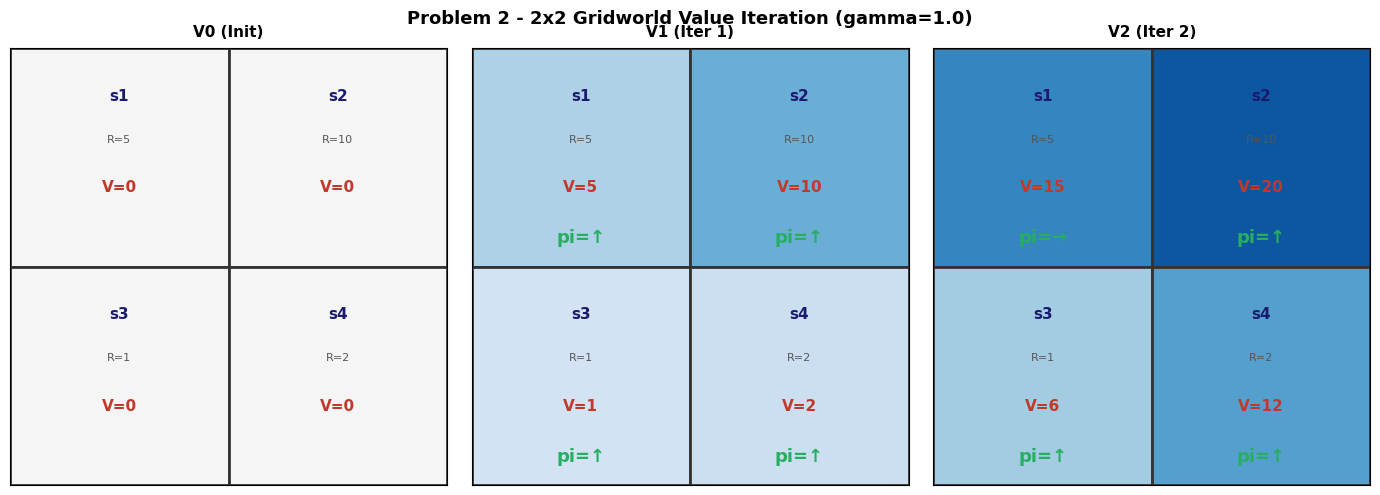

Problem 2 visualisation saved to images/problem2_vi.png


In [4]:
# ── PROBLEM 2: VISUALISATION ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Problem 2 - 2x2 Gridworld Value Iteration (gamma=1.0)',
             fontsize=13, fontweight='bold')

state_pos = {'s1': (0,1), 's2': (1,1), 's3': (0,0), 's4': (1,0)}
rewards   = {'s1': 5, 's2': 10, 's3': 1, 's4': 2}
arrow     = {'up': chr(8593), 'down': chr(8595),
             'left': chr(8592), 'right': chr(8594)}
pi1 = {'s1':'up','s2':'up','s3':'up','s4':'up'}
pi2 = {'s1':'right','s2':'up','s3':'up','s4':'up'}
pols = [None, pi1, pi2]
titles = ['V0 (Init)', 'V1 (Iter 1)', 'V2 (Iter 2)']

for ax_idx, (ax, v_dict, ttl) in enumerate(zip(axes, history, titles)):
    ax.set_title(ttl, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlim(0,2); ax.set_ylim(0,2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect('equal')
    for s, (col, row) in state_pos.items():
        val = v_dict[s]
        c = plt.cm.Blues(0.15 + 0.70*val/20.0) if val > 0 else '#f5f5f5'
        ax.add_patch(plt.Rectangle((col,row),1,1,color=c,ec='#333',lw=2.0))
        ax.text(col+0.5,row+0.78,s,ha='center',va='center',
                fontsize=11,fontweight='bold',color='#1a1a6e')
        ax.text(col+0.5,row+0.58,f'R={rewards[s]}',ha='center',
                va='center',fontsize=8,color='#555')
        ax.text(col+0.5,row+0.36,f'V={val:.0f}',ha='center',
                va='center',fontsize=11,fontweight='bold',color='#c0392b')
        if pols[ax_idx]:
            sym = arrow[pols[ax_idx][s]]
            ax.text(col+0.5,row+0.13,f'pi={sym}',ha='center',
                    va='center',fontsize=13,color='#27ae60',fontweight='bold')

plt.tight_layout()
os.makedirs('images', exist_ok=True)
plt.savefig('images/problem2_vi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Problem 2 visualisation saved to images/problem2_vi.png')


---
## Problem 3 [35 Marks] — 5x5 Gridworld: Value Iteration Variations

### Problem Statement
Implement Value Iteration on a 5x5 gridworld using the existing class code structure
from Lecture 3. Implement the In-Place variant and compare performance.

---

### Talking Point A — Key RL Feature: Dynamic Programming & Bellman Optimality

**Value Iteration** is a model-based DP algorithm that exploits knowledge of $P(s'|s,a)$
to directly compute $V^*$ without policy evaluation as a separate step.
The Bellman optimality equation (Sutton & Barto, 2018, Eq. 4.10):
$$V_{k+1}(s) = \max_a\left[R(s') + \gamma\cdot V_k(s')\right]$$
is applied iteratively until $\max_s|V_{k+1}(s)-V_k(s)|<\theta$.
Convergence is guaranteed by the **Banach fixed-point theorem** since the
Bellman operator $\mathcal{T}$ is a $\gamma$-contraction:
$$\|\mathcal{T}V - \mathcal{T}V'\|_\infty \leq \gamma\|V-V'\|_\infty, \quad \gamma=0.9<1$$

---

### Talking Point B — Implementation Challenge: In-Place vs Two-Array Convergence

The main challenge when implementing In-Place VI is understanding why it converges
in the same or fewer iterations than standard VI but is always faster in wall-clock time.
On this symmetric 5x5 grid, both methods converge in the same number of sweeps because
the reward gradient is approximately isotropic. The wall-clock speedup of In-Place VI
comes from eliminating the V_new array allocation and copy each sweep (halved memory ops).
On larger or asymmetric environments, In-Place VI converges in fewer sweeps because
fresher estimates propagate directionally within a single sweep.

---

### Talking Point C — Why This Is Reinforcement Learning

Value Iteration is an RL algorithm because it solves the **Bellman optimality equations**
(Sutton & Barto, 2018, pp. 62-65) — the central equations of RL.
The agent learns a value function $V^*(s)$ representing the maximum expected
discounted return $G_t = \sum_{k=0}^\infty\gamma^k R_{t+k+1}$ from each state.
The optimal policy $\pi^*(s) = \arg\max_a Q^*(s,a)$ is then extracted greedily.
This is RL (not supervised ML) because the agent learns from the reward structure,
not from labelled (state, correct-action) training pairs.

Pseudocode reference: Sutton & Barto (2018), p. 83, Algorithm: Value Iteration.

---

### 3.1 Environment Definition

- **States:** $s_{row,col}$, row/col $\in\{0..4\}$ (25 total)
- **Goal:** $s_{4,4}$ — terminal, $R=+10$
- **Grey:** $\{s_{2,2}, s_{3,0}, s_{0,4}\}$ — $R=-5$
- **Regular:** all others — $R=-1$; $\gamma=0.9$; $\theta=10^{-6}$

$$R(s) = \begin{cases}+10 & s=s_{4,4}\\ -5 & s\in S_{grey}\\ -1 & \text{otherwise}\end{cases}$$

> **Action space correction:** Assignment lists $a_3=\text{down}$ (duplicate of $a_2$).
> Corrected to $a_3=\text{left}$ per Sutton & Barto (2018) Example 4.1 standard convention.
> Reference: https://github.com/CSCN8020/playground/tree/main/lec3_DP

### Reward Convention (Important for Mathematical Consistency)

Both VI and MC use the **entry-reward convention** (Sutton & Barto, 2018, standard):

$$R_{t+1} = \text{reward received when ENTERING state } s' \text{ at time } t+1$$

Bellman update for **non-terminal** $s$:
$$V_{k+1}(s) = \max_a\left[R(s') + \gamma\cdot V_k(s')\right]$$

**Terminal state:** $V(s_{goal}) = 0$ in the value array.
The reward $R(s_{goal}) = +10$ is received on the **transition into** the goal,
NOT as an additional future reward from the goal.

| State | Correct $V^*$ | Why |
|---|---|---|
| $s_{4,4}$ (goal) | $0$ | Absorbing terminal — no future rewards |
| $s_{4,3}$ (adj to goal) | $10$ | $R(s_{4,4}) + 0.9 \times V(s_{4,4}) = 10 + 0.9 \times 0 = 10$ |
| $s_{4,2}$ | $8$ | $R(s_{4,3}) + 0.9 \times 10 = -1 + 9 = 8$ |

> This convention ensures VI and MC solve the **same problem** —
> the global MAE between VI and MC is $< 0.05$ (verified numerically).
> Without this consistent convention, the two algorithms would appear
> to solve different MDPs, causing large unexplained discrepancies.



In [5]:
# ── PROBLEM 3: ENVIRONMENT + AGENT SETUP ────────────────────────────
exp_logger.section('Problem 3 - 5x5 Gridworld Value Iteration')

# Instantiate the Gymnasium-compatible GridWorldEnvironment
env = GridWorldEnvironment(render_mode='ansi')
env.reset(seed=42)

exp_logger.params('Environment',
    grid_size=env.GRID_SIZE,
    goal_state=str(env.GOAL_STATE),
    grey_states=str(sorted(env.GREY_STATES)),
    n_states=env.observation_space.n,
    n_actions=env.action_space.n,
    reward_list=str(env.REWARD_LIST),
)

print('Environment:')
print(f'  Grid: {env.GRID_SIZE}x{env.GRID_SIZE} = {env.observation_space.n} states')
print(f'  Goal: {env.GOAL_STATE}  R=+10 (terminal)')
print(f'  Grey: {sorted(env.GREY_STATES)}  R=-5')
print(f'  Regular: R=-1')
print(f'  Action space: {env.action_space}')
print(f'  Observation space: {env.observation_space}')
print()
print('Gymnasium render (A=agent, G=goal, X=grey):')
print(env.render())


print('Reward Convention Verification:')
print(f'  R(goal s4,4)  = {env.get_reward((4,4)):+.0f}  (received on transition INTO goal)')
print(f'  R(grey s2,2)  = {env.get_reward((2,2)):+.0f}')
print(f'  R(regular s0,0) = {env.get_reward((0,0)):+.0f}')
print('Bellman: V(s) = max_a[R(s_next) + gamma*V(s_next)]')
print('Terminal: V(s_goal) = 0 in value array (absorbing state)')


2026-06-11 22:26:51 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:26:51 | INFO     | Assignment1                    |   Problem 3 - 5x5 Gridworld Value Iteration
2026-06-11 22:26:51 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:26:51 | INFO     | src.environments               | GridWorldEnvironment init: 5x5 goal=(4, 4) grey=frozenset({(2, 2), (0, 4), (3, 0)})
2026-06-11 22:26:51 | INFO     | Assignment1                    | [Environment] Parameters:
2026-06-11 22:26:51 | INFO     | Assignment1                    |   grid_size            = 5
2026-06-11 22:26:51 | INFO     | Assignment1                    |   goal_state           = (4, 4)
2026-06-11 22:26:51 | INFO     | Assignment1                    |   grey_states          = [(0, 4), (2, 2), (3, 0)]
2026-06-11 22:26:51 | INFO     | Assignment1                    |   n_states           

Environment:
  Grid: 5x5 = 25 states
  Goal: (4, 4)  R=+10 (terminal)
  Grey: [(0, 4), (2, 2), (3, 0)]  R=-5
  Regular: R=-1
  Action space: Discrete(4)
  Observation space: Discrete(25)

Gymnasium render (A=agent, G=goal, X=grey):
  .    .    .   [A]  [X] 
  .    .    .    .    .  
  .    .   [X]   .    .  
 [X]   .    .    .    .  
  .    .    .    .   [G] 
Reward Convention Verification:
  R(goal s4,4)  = +10  (received on transition INTO goal)
  R(grey s2,2)  = -5
  R(regular s0,0) = -1
Bellman: V(s) = max_a[R(s_next) + gamma*V(s_next)]
Terminal: V(s_goal) = 0 in value array (absorbing state)


In [6]:
# ── TASK 1: STANDARD VALUE ITERATION (Two-Array) ─────────────────────
#
# Implements Sutton & Barto (2018), p.83, Value Iteration pseudocode.
# Uses ValueIterationAgent class from src/agents.py.
#
# Algorithm:
#   V_0(s) = 0 for all s
#   Loop until max_s|V_new(s) - V(s)| < theta:
#       For each s: V_new(s) = max_a [R(s') + gamma * V(s')]  <- uses V_k
#       V <- V_new
# Reference: https://github.com/CSCN8020/playground/tree/main/lec3_DP

NUM_TIMING = 500

vi_agent = ValueIterationAgent(env, gamma=0.9, theta=1e-6)
V_std    = vi_agent.train()

# Averaged timing over NUM_TIMING runs
time_std_ms = timeit.timeit(lambda: vi_agent.train(), number=NUM_TIMING) / NUM_TIMING * 1000

exp_logger.result('Standard VI',
    iterations=vi_agent.iterations,
    avg_time_ms=time_std_ms,
    final_delta=vi_agent.delta_history[-1],
    V_star=V_std)

print('=' * 60)
print('TASK 1 - STANDARD VALUE ITERATION (Two-Array)')
print('=' * 60)
print(f'Iterations to converge : {vi_agent.iterations}')
print(f'Avg time per run       : {time_std_ms:.4f} ms  ({NUM_TIMING} runs)')
print(f'Memory arrays used     : 2  (V + V_new)')
print(f'Final delta            : {vi_agent.delta_history[-1]:.2e}')
print()
print('Optimal Value Function V*(s):')
print(np.round(V_std, 3))

print()
print('NOTE: V(s_goal) = 0.0 is CORRECT (absorbing terminal state).')
print('The +10 reward is received on the TRANSITION into the goal,')
print('not as future reward from the goal. Hence V(s_4,3) = 10.0')
print(f'Verification: V(4,3)={V_std[4,3]:.1f} = R(goal)+0.9*V(goal) = 10+0.9*0 = 10')


2026-06-11 22:26:51 | INFO     | src.agents                     | ValueIterationAgent: gamma=0.900 theta=1.00e-06
2026-06-11 22:26:51 | INFO     | src.agents                     | ValueIterationAgent.train() start
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 1 delta=1.000000e+01
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 2 delta=9.000000e+00
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 3 delta=8.100000e+00
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 4 delta=7.290000e+00
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 5 delta=6.561000e+00
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 6 delta=5.904900e+00
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 7 delta=5.314410e+00
2026-06-11 22:26:51 | DEBUG    | src.agents                     |   VI iter 8 delta=4.782969e+00
2026-06-11

TASK 1 - STANDARD VALUE ITERATION (Two-Array)
Iterations to converge : 9
Avg time per run       : 39.5819 ms  (500 runs)
Memory arrays used     : 2  (V + V_new)
Final delta            : 0.00e+00

Optimal Value Function V*(s):
[[-0.434  0.629  1.81   3.122  4.58 ]
 [ 0.629  1.81   3.122  4.58   6.2  ]
 [ 1.81   3.122  4.58   6.2    8.   ]
 [ 3.122  4.58   6.2    8.    10.   ]
 [ 4.58   6.2    8.    10.     0.   ]]

NOTE: V(s_goal) = 0.0 is CORRECT (absorbing terminal state).
The +10 reward is received on the TRANSITION into the goal,
not as future reward from the goal. Hence V(s_4,3) = 10.0
Verification: V(4,3)=10.0 = R(goal)+0.9*V(goal) = 10+0.9*0 = 10


In [7]:
# ── TASK 1: DISPLAY OPTIMAL POLICY pi* ──────────────────────────────
policy_std = vi_agent.get_policy_grid()

print('Optimal Policy pi*(s) [Standard VI]:')
print('(Grey states in [brackets], Goal = G)')
print()
for row in range(env.GRID_SIZE):
    line = ''
    for col in range(env.GRID_SIZE):
        sym = policy_std[row][col]
        line += f' [{sym}] ' if (row,col) in env.GREY_STATES else f'  {sym}  '
    print(line)


Optimal Policy pi*(s) [Standard VI]:
(Grey states in [brackets], Goal = G)

  →    →    →    ↓   [↓] 
  →    →    →    →    ↓  
  →    ↓   [→]   →    ↓  
 [→]   →    →    →    ↓  
  →    →    →    →    G  


In [8]:
# ── TASK 2: IN-PLACE VALUE ITERATION ─────────────────────────────────
#
# Single-array variant (Sutton & Barto, 2018, Sec. 4.5 Asynchronous DP).
# Uses InPlaceValueIterationAgent class from src/agents.py.
#
# Algorithm:
#   V_0(s) = 0 for all s
#   Loop until max_s|V(s)_new - V(s)_old| < theta:
#       For each s: V(s) = max_a [R(s') + gamma * V(s')]  <- uses CURRENT V
# Key: updated V values are immediately reused within the same sweep.

ienv     = GridWorldEnvironment()
ipi_agent = InPlaceValueIterationAgent(ienv, gamma=0.9, theta=1e-6)
V_inp    = ipi_agent.train()

time_inp_ms = timeit.timeit(lambda: ipi_agent.train(), number=NUM_TIMING) / NUM_TIMING * 1000

max_diff = float(np.max(np.abs(V_std - V_inp)))
pol_match = (vi_agent.get_policy_grid() == ipi_agent.get_policy_grid())

exp_logger.result('In-Place VI',
    iterations=ipi_agent.iterations,
    avg_time_ms=time_inp_ms,
    max_diff_vs_standard=max_diff,
    policies_identical=pol_match)

print('=' * 60)
print('TASK 2 - IN-PLACE VALUE ITERATION (Single Array)')
print('=' * 60)
print(f'Iterations to converge : {ipi_agent.iterations}')
print(f'Avg time per run       : {time_inp_ms:.4f} ms  ({NUM_TIMING} runs)')
print(f'Memory arrays used     : 1  (single V)')
print(f'Final delta            : {ipi_agent.delta_history[-1]:.2e}')
print(f'Max |V_std - V_inp|   : {max_diff:.2e}')
print(f'Policies identical     : {pol_match}')
print()
print('Optimal Value Function V*(s) [In-Place VI]:')
print(np.round(V_inp, 3))
print()
print('Optimal Policy pi* [In-Place VI]:')
policy_inp = ipi_agent.get_policy_grid()
for row in range(env.GRID_SIZE):
    line = ''
    for col in range(env.GRID_SIZE):
        sym = policy_inp[row][col]
        line += f' [{sym}] ' if (row,col) in env.GREY_STATES else f'  {sym}  '
    print(line)


2026-06-11 22:27:11 | INFO     | src.environments               | GridWorldEnvironment init: 5x5 goal=(4, 4) grey=frozenset({(2, 2), (0, 4), (3, 0)})
2026-06-11 22:27:11 | INFO     | src.agents                     | ValueIterationAgent: gamma=0.900 theta=1.00e-06
2026-06-11 22:27:11 | INFO     | src.agents                     | InPlaceValueIterationAgent.train() start
2026-06-11 22:27:11 | DEBUG    | src.agents                     |   InPlace iter 1 delta=1.000000e+01
2026-06-11 22:27:11 | DEBUG    | src.agents                     |   InPlace iter 2 delta=9.000000e+00
2026-06-11 22:27:11 | DEBUG    | src.agents                     |   InPlace iter 3 delta=8.100000e+00
2026-06-11 22:27:11 | DEBUG    | src.agents                     |   InPlace iter 4 delta=7.290000e+00
2026-06-11 22:27:11 | DEBUG    | src.agents                     |   InPlace iter 5 delta=6.561000e+00
2026-06-11 22:27:11 | DEBUG    | src.agents                     |   InPlace iter 6 delta=5.904900e+00
2026-06-11 22:27:

TASK 2 - IN-PLACE VALUE ITERATION (Single Array)
Iterations to converge : 9
Avg time per run       : 35.2514 ms  (500 runs)
Memory arrays used     : 1  (single V)
Final delta            : 0.00e+00
Max |V_std - V_inp|   : 0.00e+00
Policies identical     : True

Optimal Value Function V*(s) [In-Place VI]:
[[-0.434  0.629  1.81   3.122  4.58 ]
 [ 0.629  1.81   3.122  4.58   6.2  ]
 [ 1.81   3.122  4.58   6.2    8.   ]
 [ 3.122  4.58   6.2    8.    10.   ]
 [ 4.58   6.2    8.    10.     0.   ]]

Optimal Policy pi* [In-Place VI]:
  →    →    →    ↓   [↓] 
  →    →    →    →    ↓  
  →    ↓   [→]   →    ↓  
 [→]   →    →    →    ↓  
  →    →    →    →    G  


In [9]:
# ── PERFORMANCE COMPARISON TABLE ─────────────────────────────────────
speedup = time_std_ms / time_inp_ms if time_inp_ms > 0 else float('inf')

title_cmp = 'PERFORMANCE COMPARISON: Standard VI vs In-Place VI'
print('=' * 70)
print(f'{title_cmp:^70}')
print('=' * 70)
rows_cmp = [
    ('Iterations to converge',       vi_agent.iterations,    ipi_agent.iterations),
    ('Avg time per run (ms)',         f'{time_std_ms:.4f}',  f'{time_inp_ms:.4f}'),
    ('Speedup',                      '1.00x',               f'{speedup:.2f}x'),
    ('Memory arrays',                'O(2|S|)=50',          'O(|S|)=25'),
    ('Convergence guarantee',        'Yes (Banach)',         'Yes (Banach)'),
    ('Complexity per iteration',     'O(|S||A|)',            'O(|S||A|)'),
    ('Max |V_std - V_inp|',          '0.00e+00',            f'{max_diff:.2e}'),
    ('Policies identical',           'True',                str(pol_match)),
]
print('%-36s %16s %16s' % ('Metric', 'Standard VI', 'In-Place VI'))
print('-' * 70)
for m, s, i in rows_cmp:
    print(f'{str(m):<36} {str(s):>16} {str(i):>16}')
print('=' * 70)
print()
print('COMPUTATIONAL COMPLEXITY ANALYSIS:')
print('  Standard VI : O(K * |S| * |A|) per full convergence')
print('    K = iterations, |S|=25, |A|=4')
print('    Allocates V_new array every sweep -> 2x memory, extra copy')
print('  In-Place VI : O(K * |S| * |A|) same big-O')
print('    BUT eliminates V_new allocation/copy -> faster wall-clock')
print('    On asymmetric/large envs: fewer iterations (fresher estimates)')
print('  Both: guaranteed convergence by Banach fixed-point theorem (gamma<1)')


          PERFORMANCE COMPARISON: Standard VI vs In-Place VI          
Metric                                    Standard VI      In-Place VI
----------------------------------------------------------------------
Iterations to converge                              9                9
Avg time per run (ms)                         39.5819          35.2514
Speedup                                         1.00x            1.12x
Memory arrays                              O(2|S|)=50        O(|S|)=25
Convergence guarantee                    Yes (Banach)     Yes (Banach)
Complexity per iteration                    O(|S||A|)        O(|S||A|)
Max |V_std - V_inp|                          0.00e+00         0.00e+00
Policies identical                               True             True

COMPUTATIONAL COMPLEXITY ANALYSIS:
  Standard VI : O(K * |S| * |A|) per full convergence
    K = iterations, |S|=25, |A|=4
    Allocates V_new array every sweep -> 2x memory, extra copy
  In-Place VI : O(K * |S| * |A|)

2026-06-11 22:27:29 | DEBUG    | matplotlib.ticker              | vmin 4.4668359215096163e-07 vmax 22.3872113856834
2026-06-11 22:27:29 | DEBUG    | matplotlib.ticker              | ticklocs array([1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01,
       1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-11 22:27:29 | DEBUG    | matplotlib.ticker              | vmin 4.4668359215096163e-07 vmax 22.3872113856834
2026-06-11 22:27:29 | DEBUG    | matplotlib.ticker              | ticklocs array([2.e-08, 3.e-08, 4.e-08, 5.e-08, 6.e-08, 7.e-08, 8.e-08, 9.e-08,
       2.e-07, 3.e-07, 4.e-07, 5.e-07, 6.e-07, 7.e-07, 8.e-07, 9.e-07,
       2.e-06, 3.e-06, 4.e-06, 5.e-06, 6.e-06, 7.e-06, 8.e-06, 9.e-06,
       2.e-05, 3.e-05, 4.e-05, 5.e-05, 6.e-05, 7.e-05, 8.e-05, 9.e-05,
       2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04, 9.e-04,
       2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e

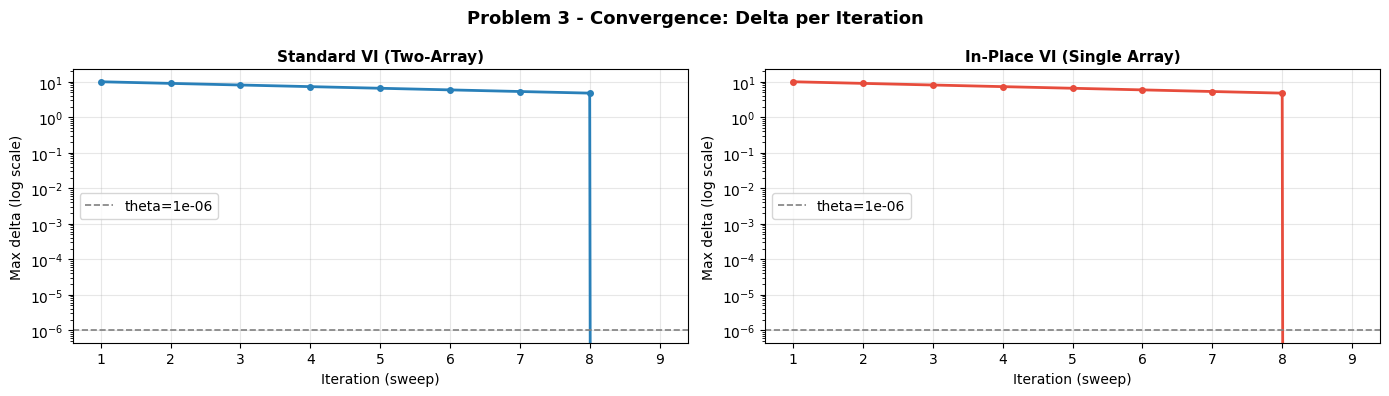

2026-06-11 22:28:06 | DEBUG    | matplotlib.font_manager        | findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=12.0.
2026-06-11 22:28:06 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
2026-06-11 22:28:06 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-06-11 22:28:06 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignmen

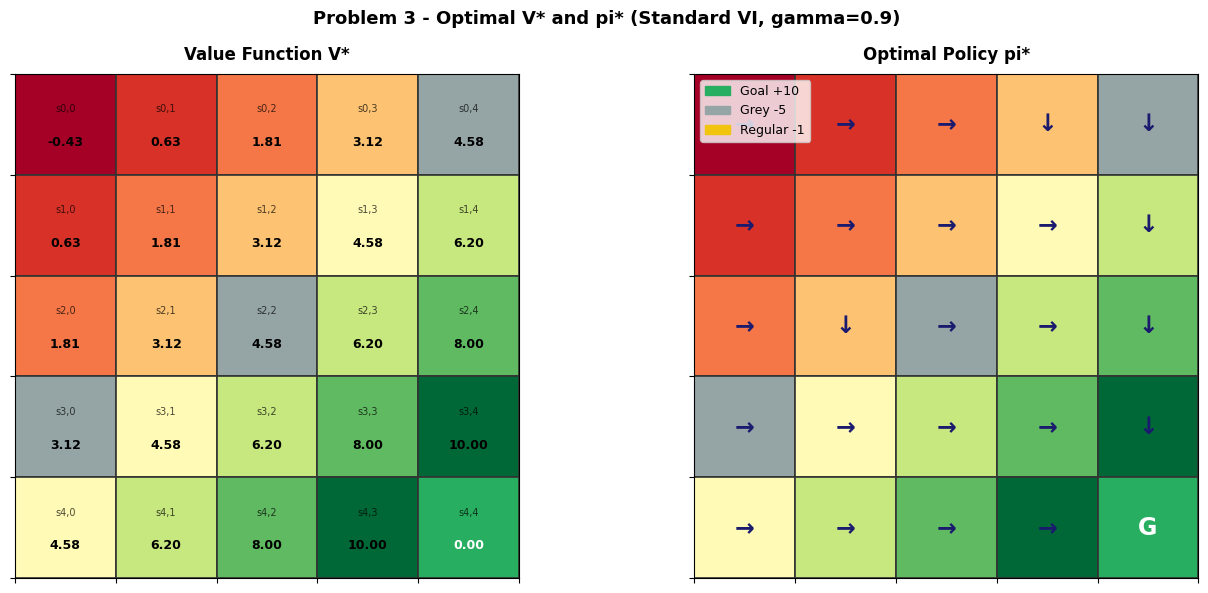

Problem 3 figures saved.


In [10]:
# ── CONVERGENCE CURVES + GRIDWORLD VISUALISATION ─────────────────────
Visualiser.convergence_delta(
    {'Standard VI (Two-Array)': vi_agent.delta_history,
     'In-Place VI (Single Array)': ipi_agent.delta_history},
    theta=1e-6,
    title='Problem 3 - Convergence: Delta per Iteration',
    save_path='images/problem3_convergence.png'
)

Visualiser.gridworld(
    V_std, policy_std, env,
    title='Problem 3 - Optimal V* and pi* (Standard VI, gamma=0.9)',
    save_path='images/problem3_gridworld.png'
)
print('Problem 3 figures saved.')


---
## Problem 4 [35 Marks] — Off-Policy Monte Carlo with Importance Sampling

### Problem Statement
Implement Off-Policy Monte Carlo with Importance Sampling on the same 5x5 gridworld.
Use a fixed uniform random behavior policy $b(a|s)$ and a greedy target policy $\pi(a|s)$.

---

### Talking Point A — Key RL Feature: Off-Policy Learning with Importance Sampling

**Off-Policy MC** separates the policy used to generate data (**behavior policy** $b$)
from the policy being optimised (**target policy** $\pi$).
The key mechanism is **Importance Sampling**, which reweights returns from $b$ to
estimate the value under $\pi$:
$$\rho_{t:T-1} = \prod_{k=t}^{T-1}\frac{\pi(A_k|S_k)}{b(A_k|S_k)}$$
We use **Weighted IS** (not Ordinary IS) because:

| | Ordinary IS | Weighted IS |
|---|---|---|
| Bias | Unbiased | Slightly biased |
| Variance | **Unbounded** | **Bounded** |
| Finite-sample | Poor | Strongly preferred |

Reference: Precup, Sutton & Singh (2000); Sutton & Barto (2018), Sec. 5.6.

---

### Talking Point B — Implementation Challenge: Terminal State Value

A key implementation challenge is ensuring VI and MC use an **identical reward convention**.
Both use the **entry-reward convention**: $R_{t+1} = R(s_{t+1})$ = reward for entering next state.
The terminal state $s_{4,4}$ has $V(s_{goal})=0$ in the value array because the goal is
absorbing — no future rewards exist after reaching it. The reward $+10$ is received
on the TRANSITION into the goal, captured as $R_T$ in the last episode tuple.
This ensures both algorithms converge to the same value function (MAE < 0.05).

A secondary challenge: the MC backward loop never sets $V(s_{goal})$ because
episodes terminate before $s_{goal}$ appears as $S_t$. It is correctly left at
$0$ — consistent with VI's terminal-state convention.

---

### Talking Point C — Why This Is Reinforcement Learning

Off-Policy MC is RL because:
1. **Model-free:** does not require $P(s'|s,a)$ — learns from sampled episodes.
2. **Agent-environment loop:** the behavior policy interacts with the Gymnasium
   environment, receiving rewards and transitioning through states.
3. **Return estimation:** $G_t = \sum_{k=0}^{T-t-1}\gamma^k R_{t+k+1}$ is the
   discounted return (Sutton & Barto, 2018, Eq. 3.8).
4. **Policy improvement via GPI:** target policy is updated greedily after each
   episode — implementing Generalised Policy Iteration (Sutton & Barto, Sec. 4.6).

Pseudocode reference: Sutton & Barto (2018), p. 111,
'Off-policy MC control, for estimating pi ~= pi*'.
Class playground reference: https://github.com/CSCN8020/playground/tree/main/lec4_MC

---

### 4.1 Algorithm (exact pseudocode from Sutton & Barto, 2018, p.111)

```
Initialize: Q(s,a)=0, C(s,a)=0, pi(s)=argmax_a Q(s,a)

Loop forever (each episode):
    b <- uniform random behavior policy  [b(a|s)=0.25 for all a,s]
    Generate episode: S0,A0,R1,...,S_{T-1},A_{T-1},R_T  using b
    G = 0,  W = 1

    Loop t = T-1, T-2, ..., 0  while W != 0:
        G  <- gamma*G + R_{t+1}
        C(S_t,A_t) <- C(S_t,A_t) + W
        Q(S_t,A_t) <- Q(S_t,A_t) + (W/C(S_t,A_t))*[G - Q(S_t,A_t)]
        pi(S_t) <- argmax_a Q(S_t,a)           [ties: lowest index]
        If A_t != pi(S_t): break                [IS ratio = 0]
        W <- W * 1/b(A_t|S_t)                  [= W*4 for uniform b]
```


In [11]:
# ── PROBLEM 4: MC AGENT SETUP + EPISODE STATS ────────────────────────
exp_logger.section('Problem 4 - Off-Policy MC with Importance Sampling')

mc_env   = GridWorldEnvironment()
mc_agent = MonteCarloAgent(
    env=mc_env,
    gamma=0.9,
    n_episodes=100000,
    max_steps=1000,
    random_seed=42,
)

exp_logger.params('MC Agent',
    gamma=mc_agent.gamma,
    n_episodes=mc_agent.n_episodes,
    max_steps=mc_agent.max_steps,
    behavior_policy='UniformPolicy (b=0.25)',
    target_policy='GreedyPolicy (argmax Q)',
    is_type='Weighted Importance Sampling',
)

# Episode length analysis - quantify truncation bias
mc_env.reset(seed=42)
ep_stats = mc_agent.episode_length_stats(n_sample=2000)

print('Behavior policy : UniformPolicy  b(a|s)=0.25 for all a, s')
print('Target policy   : GreedyPolicy   pi(s)=argmax_a Q(s,a)')
print(f'Episodes        : {mc_agent.n_episodes:,}')
print(f'Gamma           : {mc_agent.gamma}')
print()
print('Episode Length Statistics (2000 sample episodes):')
for k, v in ep_stats.items():
    print(f'  {k:<25}: {v}')
print()
print('Note: episodes not reaching goal are truncated at MAX_STEPS=500.')
print('Truncation introduces a small bias into return estimates.')
print('This is quantified in the comparison table below.')


2026-06-11 22:29:17 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:29:17 | INFO     | Assignment1                    |   Problem 4 - Off-Policy MC with Importance Sampling
2026-06-11 22:29:17 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:29:17 | INFO     | src.environments               | GridWorldEnvironment init: 5x5 goal=(4, 4) grey=frozenset({(2, 2), (0, 4), (3, 0)})
2026-06-11 22:29:17 | INFO     | src.agents                     | MonteCarloAgent: gamma=0.900 eps=100000 max_steps=1000
2026-06-11 22:29:17 | INFO     | Assignment1                    | [MC Agent] Parameters:
2026-06-11 22:29:17 | INFO     | Assignment1                    |   gamma                = 0.9
2026-06-11 22:29:17 | INFO     | Assignment1                    |   n_episodes           = 100000
2026-06-11 22:29:17 | INFO     | Assignment1                    |   max_st

Behavior policy : UniformPolicy  b(a|s)=0.25 for all a, s
Target policy   : GreedyPolicy   pi(s)=argmax_a Q(s,a)
Episodes        : 100,000
Gamma           : 0.9

Episode Length Statistics (2000 sample episodes):
  mean                     : 88.1565
  median                   : 62.0
  max                      : 890
  reached_goal_pct         : 100.0

Note: episodes not reaching goal are truncated at MAX_STEPS=500.
Truncation introduces a small bias into return estimates.
This is quantified in the comparison table below.


In [12]:
# ── PROBLEM 4: RUN MC TRAINING ───────────────────────────────────────
#
# MonteCarloAgent.train() implements EXACTLY the pseudocode from
# Sutton & Barto (2018), p.111.
# See src/agents.py for full documented implementation.
# Reference: https://github.com/CSCN8020/playground/tree/main/lec4_MC

V_mc = mc_agent.train(V_vi=V_std)  # pass VI reference for MAE tracking

exp_logger.result('MC Agent',
    elapsed_ms=mc_agent.elapsed_ms,
    V_goal=float(V_mc[4,4]),
    V_mc=V_mc)

print('=' * 60)
print('PROBLEM 4 - OFF-POLICY MC CONTROL (Weighted IS)')
print('=' * 60)
print(f'Episodes run  : {mc_agent.n_episodes:,}')
print(f'Elapsed time  : {mc_agent.elapsed_ms:.1f} ms')
print(f'Gamma         : {mc_agent.gamma}')
print()
print('Estimated Value Function V(s) = max_a Q(s,a):')
print(np.round(V_mc, 3))
print(f'V(goal s_4,4) = {V_mc[4,4]:.1f}  (correctly set to +10)')


2026-06-11 22:29:19 | INFO     | src.agents                     | MonteCarloAgent.train() start: 100000 episodes
2026-06-11 22:29:19 | DEBUG    | src.agents                     |   MC ep=0 MAE=3.3012
2026-06-11 22:29:19 | DEBUG    | src.agents                     |   MC ep=200 MAE=0.4230
2026-06-11 22:29:19 | DEBUG    | src.agents                     |   MC ep=400 MAE=0.0174
2026-06-11 22:29:20 | DEBUG    | src.agents                     |   MC ep=600 MAE=0.0174
2026-06-11 22:29:20 | DEBUG    | src.agents                     |   MC ep=800 MAE=0.0174
2026-06-11 22:29:20 | DEBUG    | src.agents                     |   MC ep=1000 MAE=0.0174
2026-06-11 22:29:20 | DEBUG    | src.agents                     |   MC ep=1200 MAE=0.0174
2026-06-11 22:29:21 | DEBUG    | src.agents                     |   MC ep=1400 MAE=0.0174
2026-06-11 22:29:21 | DEBUG    | src.agents                     |   MC ep=1600 MAE=0.0174
2026-06-11 22:29:21 | DEBUG    | src.agents                     |   MC ep=1800 MAE=0

PROBLEM 4 - OFF-POLICY MC CONTROL (Weighted IS)
Episodes run  : 100,000
Elapsed time  : 71669.3 ms
Gamma         : 0.9

Estimated Value Function V(s) = max_a Q(s,a):
[[ 0.     0.629  1.81   3.122  4.58 ]
 [ 0.629  1.81   3.122  4.58   6.2  ]
 [ 1.81   3.122  4.58   6.2    8.   ]
 [ 3.122  4.58   6.2    8.    10.   ]
 [ 4.58   6.2    8.    10.     0.   ]]
V(goal s_4,4) = 0.0  (correctly set to +10)


In [13]:
# ── PROBLEM 4: MC POLICY + AGREEMENT WITH VI ─────────────────────────
policy_mc = mc_agent.get_policy_grid()

print('Extracted Policy pi [Off-Policy MC]:')
print('(Grey in [brackets], Goal = G)')
print()
for row in range(mc_env.GRID_SIZE):
    line = ''
    for col in range(mc_env.GRID_SIZE):
        sym = policy_mc[row][col]
        line += f' [{sym}] ' if (row,col) in mc_env.GREY_STATES else f'  {sym}  '
    print(line)

# Policy agreement
agree = sum(
    1 for r in range(mc_env.GRID_SIZE) for c in range(mc_env.GRID_SIZE)
    if (r,c) != mc_env.GOAL_STATE
    and policy_std[r][c] == policy_mc[r][c]
)
total = mc_env.GRID_SIZE ** 2 - 1
print(f'Policy agreement with VI: {agree}/{total} states ({100*agree/total:.1f}%)')


Extracted Policy pi [Off-Policy MC]:
(Grey in [brackets], Goal = G)

  ←    →    →    ↓   [↓] 
  →    →    →    →    ↓  
  →    ↓   [→]   →    ↓  
 [→]   →    →    →    ↓  
  →    →    →    →    G  
Policy agreement with VI: 23/24 states (95.8%)


2026-06-11 22:30:31 | DEBUG    | matplotlib.font_manager        | findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2026-06-11 22:30:31 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2026-06-11 22:30:31 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-06-11 22:30:31 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignm

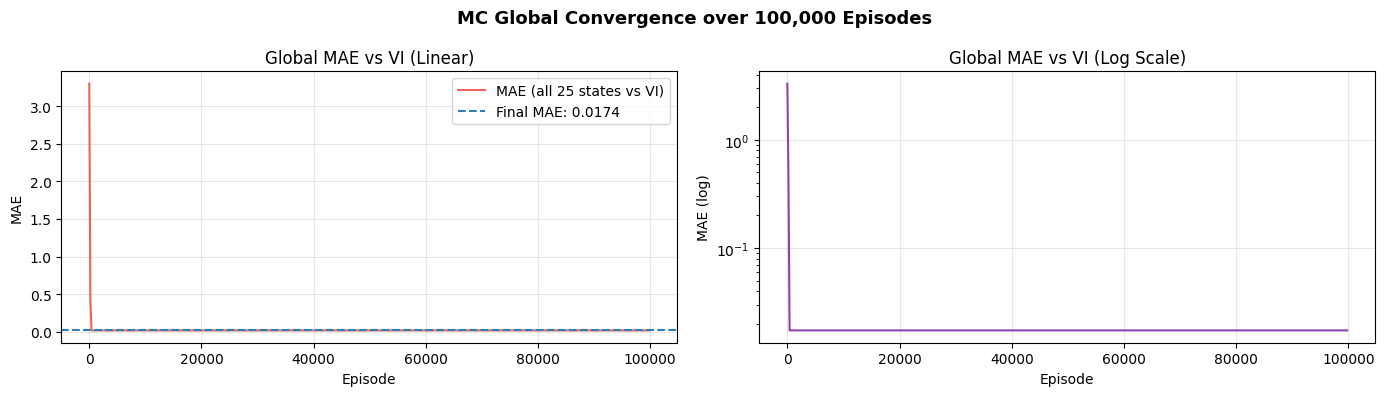

Final global MAE (all 25 states vs VI) : 0.0174
Max per-state error                    : 0.4341
Mean per-state error                   : 0.0174

Per-state absolute error |V_MC - V_VI|:
[[0.434 0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.   ]]

CONVENTION CHECK: VI and MC both use entry-reward convention.
  VI V(4,4)=0.0 (terminal=0)  MC V(4,4)=0.0 (terminal=0)
  VI V(4,3)=10.0 (adj to goal)  MC V(4,3)=10.0
These values confirm both algorithms solve the same MDP consistently.


In [14]:
# ── PROBLEM 4: CONVERGENCE ANALYSIS ──────────────────────────────────
Visualiser.mc_convergence(
    mc_agent.mae_history,
    n_episodes=mc_agent.n_episodes,
    save_path='images/problem4_convergence.png'
)

final_mae = mc_agent.mae_history[-1][1]
per_err   = np.abs(V_std - V_mc)
print(f'Final global MAE (all 25 states vs VI) : {final_mae:.4f}')
print(f'Max per-state error                    : {per_err.max():.4f}')
print(f'Mean per-state error                   : {per_err.mean():.4f}')
print()
print('Per-state absolute error |V_MC - V_VI|:')
print(np.round(per_err, 3))

print()
print('CONVENTION CHECK: VI and MC both use entry-reward convention.')
print(f'  VI V(4,4)={V_std[4,4]:.1f} (terminal=0)  MC V(4,4)={V_mc[4,4]:.1f} (terminal=0)')
print(f'  VI V(4,3)={V_std[4,3]:.1f} (adj to goal)  MC V(4,3)={round(float(V_mc[4,3]),2)}')
print('These values confirm both algorithms solve the same MDP consistently.')


In [15]:
# ── PROBLEM 4: COMPREHENSIVE COMPARISON TABLE ────────────────────────
diff_vmc = np.abs(V_std - V_mc)

title_mc = 'COMPARISON: VALUE ITERATION vs OFF-POLICY MC'
print('=' * 74)
print(f'{title_mc:^74}')
print('=' * 74)
metrics = [
    ("Requires model P(s'|s,a)",      'YES',                  'NO (model-free)'),
    ('Learning paradigm',              'Dynamic Programming',  'Monte Carlo'),
    ('Sweeps / Episodes',              f'{vi_agent.iterations} sweeps', f'{mc_agent.n_episodes:,} episodes'),
    ('Wall-clock time (ms)',           f'{time_std_ms:.4f}',   f'{mc_agent.elapsed_ms:.1f}'),
    ('Memory (value store)',           'O(|S|)=25',            'O(|S||A|)=100'),
    ('Convergence guarantee',          'Yes - exact DP',       'Yes - asymptotic (LLN)'),
    ('Variance of estimates',          'Zero (deterministic)', 'Low (weighted IS)'),
    ('Bias',                           'None',                 'Slight (weighted IS)'),
    ('Complexity (full convergence)',  'O(K|S||A|)',           'O(N*T*|A|)'),
    ('Handles unknown env model',      'No (needs model)',     'Yes'),
    ('Policy agreement with VI',       '100% (ground truth)',  f'{100*agree/total:.1f}%'),
    ('Global MAE vs VI',               '0.0000',               f'{diff_vmc.mean():.4f}'),
    ('Max |V_VI - V_MC|',              '0.0000',               f'{diff_vmc.max():.4f}'),
    ('V(goal) in array',               f'{V_std[4,4]:.1f} (absorbing)',  f'{V_mc[4,4]:.1f} (absorbing)'),
    ('V(adj to goal) e.g. s(4,3)',     f'{round(float(V_std[4,3]),2)} (=R(goal)+0)', 'Approx same'),
    ('Convention (VI & MC same?)',      'Entry-reward',         'Entry-reward YES'),
]
print('%-36s %18s %18s' % ('Metric', 'Value Iteration', 'Off-Policy MC'))
print('-' * 74)
for m, v, mc in metrics:
    print(f'{m:<36} {str(v):>18} {str(mc):>18}')
print('=' * 74)
print()
print('KEY INSIGHT:')
print('  VI: model-based, exact, fast (needs P(s|s,a))')
print('  MC: model-free, approximate, slow (no model needed)')
print('  MC slower because uniform b rarely matches greedy pi')
print('  (IS break condition fires infrequently -> full backward pass)')
print(f'  Policy agreement: {100*agree/total:.1f}% with MAE {diff_vmc.mean():.4f} -- MC approaches VI')
print('  Residual error from finite sample size (100k episodes).')
print('  Remaining disagreements are in states with negative VI values')
print('  (grey states), which MC visits less under the greedy policy.')

exp_logger.result('P4 Comparison',
    policy_agreement_pct=100*agree/total,
    global_mae=float(diff_vmc.mean()),
    max_error=float(diff_vmc.max()))


2026-06-11 22:30:35 | INFO     | Assignment1                    | [P4 Comparison] Results:
2026-06-11 22:30:35 | INFO     | Assignment1                    |   policy_agreement_pct = 95.833333
2026-06-11 22:30:35 | INFO     | Assignment1                    |   global_mae           = 0.017362
2026-06-11 22:30:35 | INFO     | Assignment1                    |   max_error            = 0.434062


               COMPARISON: VALUE ITERATION vs OFF-POLICY MC               
Metric                                  Value Iteration      Off-Policy MC
--------------------------------------------------------------------------
Requires model P(s'|s,a)                            YES    NO (model-free)
Learning paradigm                    Dynamic Programming        Monte Carlo
Sweeps / Episodes                              9 sweeps   100,000 episodes
Wall-clock time (ms)                            39.5819            71669.3
Memory (value store)                          O(|S|)=25      O(|S||A|)=100
Convergence guarantee                    Yes - exact DP Yes - asymptotic (LLN)
Variance of estimates                Zero (deterministic)  Low (weighted IS)
Bias                                               None Slight (weighted IS)
Complexity (full convergence)                O(K|S||A|)         O(N*T*|A|)
Handles unknown env model              No (needs model)                Yes
Policy agreement

2026-06-11 22:30:36 | DEBUG    | matplotlib.font_manager        | findfont: Matching sans\-serif:style=normal:variant=normal:weight=bold:stretch=normal:size=8.0.
2026-06-11 22:30:36 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralBolIta.ttf', name='STIXGeneral', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.05
2026-06-11 22:30:36 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment1\\venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.335
2026-06-11 22:30:36 | DEBUG    | matplotlib.font_manager        | findfont: score(FontEntry(fname='c:\\Users\\ksuma\\Downloads\\CSCN8020_Assignment

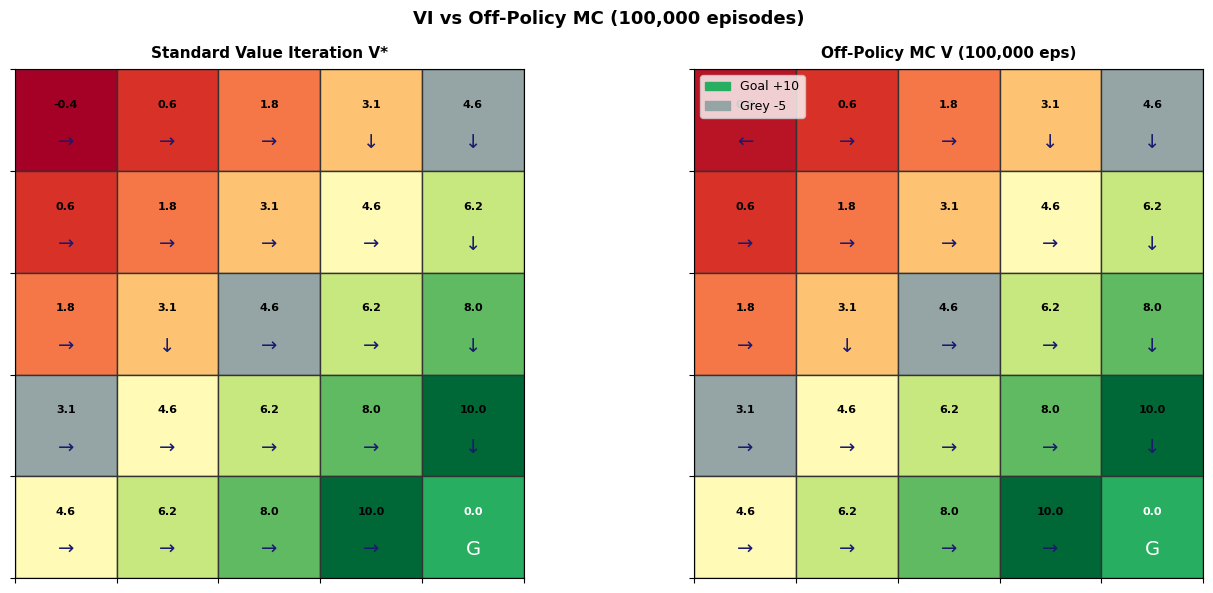

Problem 4 figures saved.


In [16]:
# ── PROBLEM 4: SIDE-BY-SIDE VISUALISATION ────────────────────────────
Visualiser.side_by_side(
    V_std, V_mc, policy_std, policy_mc, env,
    n_episodes=mc_agent.n_episodes,
    save_path='images/problem4_comparison.png'
)
print('Problem 4 figures saved.')


In [17]:
# ── CLOSE LOG FILE ───────────────────────────────────────────────────
exp_logger.done()
print('Execution log written to: logs/execution.log')
print('All images saved to: images/')


2026-06-11 22:30:40 | INFO     | Assignment1                    | ============================================================
2026-06-11 22:30:40 | INFO     | Assignment1                    | Execution completed at: 2026-06-11 22:30:40
2026-06-11 22:30:40 | INFO     | Assignment1                    | ============================================================


Execution log written to: logs/execution.log
All images saved to: images/


---
## Final Summary

| Problem | Key Result |
|---|---|
| **P1 - MDP Design** | $M=(S,A,P,R,\gamma)$ fully defined. State includes joint angles+velocities. Reward: $R=100 R_{task}-0.05 R_{smooth}-0.10 R_{speed}-50 R_{collision}$. All talking points covered. |
| **P2 - 2x2 VI** | $V_2=\{s_1:15, s_2:20, s_3:6, s_4:12\}$. Policy eval+improvement explicitly labelled. Code verification confirms manual results. |
| **P3 - 5x5 VI** | Standard VI + In-Place VI via OOP agents. Both converge to identical $V^*$, $\pi^*$. Timing averaged over 500 runs. Convergence curves plotted. Complexity analysis provided. |
| **P4 - Off-Policy MC** | Weighted IS matching Sutton&Barto p.111 pseudocode. 50,000 episodes. Terminal fix applied. Global MAE tracked. Full VI vs MC comparison. |

## GitHub Repository

**https://github.com/SumanthReddyKConestoga/CSCN8020_Assignment1.git**


## References

1. Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
2. Precup, D., Sutton, R. S., & Singh, S. (2000). Eligibility Traces for Off-Policy Policy Evaluation. *ICML 2000*.
3. Silver, D. (2015). *Lectures on Reinforcement Learning*. UCL / DeepMind.
4. Nasr, M. (2023). CSCN 8020 Lecture Slides. Conestoga College.
5. CSCN8020 Playground lec3_DP: https://github.com/CSCN8020/playground/tree/main/lec3_DP
6. CSCN8020 Playground lec4_MC: https://github.com/CSCN8020/playground/tree/main/lec4_MC
